In [1]:
# add path to sispeuede to sys.path in python
import sys
import pathlib
path_git = pathlib.Path("/Users/usuario/git")
for subdir in ["sisepuede", "sisepuede_data_pipeline"]:
    path_cur = path_git.joinpath(subdir)
    if str(path_cur) not in sys.path:
        sys.path.append(str(path_cur))


path_pipeline = path_git.joinpath("sisepuede_data_pipeline")

import warnings
warnings.filterwarnings("ignore")


import os, os.path
import numpy as np
import pandas as pd
import rioxarray as rx

#from sisepuede.core.model_attributes import *
import sisepuede.core.model_attributes as ma
import sisepuede.models.afolu as mafl
import sisepuede.models.ippu as mi
import sisepuede.models.circular_economy as mc
import sisepuede.models.energy_production as ml
import sisepuede.models.energy_consumption as me
import sisepuede.models.socioeconomic as se
import sisepuede.pipeline.projection_utilities as sppu
import sisepuede.core.model_variable as mv

#import sisepuede.legacy.setup_analysis as sa
#import sisepuede.legacy.data_api as api
import sisepuede.manager.sisepuede_models as sm
import sisepuede.core.support_classes as sc
import sisepuede.utilities._sql as squ
import sisepuede.utilities._toolbox as sf
import importlib
import pathlib
import time
import warnings
import matplotlib.pyplot as plt
from typing import *
import inspect
import sisepuede.data_management.ingestion as ing
import logging
import sisepuede.geo.geo_functions as gf
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.models.afolu as mafl
import sisepuede.transformers.lib._baselib_afolu as tba
import sisepuede.transformers.lib._baselib_circular_economy as tbc
import sisepuede.transformers.lib._baselib_energy as tbe
import sisepuede.transformers.lib._baselib_general as tbg
import sisepuede.transformers.lib._baselib_ippu as tbi
import sisepuede.utilities._plotting as spu

import afolu.geo.lib._get_gridded_dataset as gridded
import lib.data_construction_utilities as util
import lib.data_objects as do
import lib._geo as geolib
import lib._geo_classes as gcl
import lib.process_utilities as pu
import lib.sisepuede_data_constructs as dc
import lib._util as lutil



import sisepuede.models._arrays as collarrays
np.set_printoptions(linewidth = 150, )


import xarray

# Setup Paths

In [344]:
PATH_CUR = pathlib.Path(os.path.abspath("."))
PATH_DATA = PATH_CUR.joinpath("data")
PATH_DATASETS = PATH_DATA.joinpath("20260627_chen_tables", "chen_pseudo_tables", "latest")
PATH_INPUTS_SSP = PATH_DATA.joinpath("ssp_base_inputs")
PATH_INPUT_BASE = PATH_INPUTS_SSP.joinpath("sisepuede_adj_inputs_mex_20260723.csv") # add here

def get_path_to_transition_data(
    est_type: str,
    ssp_ind: int,
) -> pathlib.Path:
    """Get the path to a dataset
    """
    path_out = PATH_DATASETS.joinpath(
        est_type, 
        "baseline_glc_2020", 
        "calibration_glc_2020_plus_clipped_chen_deltas", 
        f"SSP{ssp_ind}",
        "transition_table",
    )

    return path_out

In [3]:
path_read = get_path_to_transition_data("historical_shares", 1, )
path_nc = path_read.joinpath("01.1.01.nc")



In [398]:
import lib.process_utilities as pu
import lib.sisepuede_data_constructs as dc
import lib._util as lutil
importlib.reload(dc.sc)
importlib.reload(sc)

# some globals
_MODVAR_LNDU_IBAG = matt.get_variable("Initial Above Ground Biomass Stock Factor")
_MODVAR_LNDU_RBGAG = matt.get_variable("Below Ground to Above Ground Biomass Stock Ratio")
REGION = "mexico"


##  BUILD CONSTRUCT

construct = dc.SISEPUEDEDataConstructs(
    path_output_database = "/Users/usuario/git/sisepuede_data_pipeline/sisepuede_inputs.sqlite",
)


# set some shortcuts from construct
file_struct = construct.sisepuede_file_struct
matt = file_struct.model_attributes
regions = construct.regions
time_periods = construct.time_periods

# get examples
examples = sxl.SISEPUEDEExamples()
df_examples = examples("input_data_frame").copy()

# setup AFOLU model (turn off force_lurf_for_settlements)
model_afolu = mafl.AFOLU(
    matt,
    force_lurf_for_settlements = False,
)



##  SETUP REPO

path_repo = pathlib.Path("/Users/usuario/SISEPUEDE_DATA_REPOSITORY")
repo = pu.Repository(
    {
        "local": {
            "path": str(path_repo)
        }
    }
)

# get from pipeline and add some defaults
df_from_pipeline = construct.build_inputs_from_database(
    regions_keep = REGION,
    join = "outer"
)
df_from_pipeline = _MODVAR_LNDU_RBGAG.spawn_default_dataframe(
    df_from_pipeline,
    fill_value = 0.25,
)

# read in complete DF
df_base = pd.read_csv(PATH_INPUT_BASE, )
df_input = sf.match_df_to_target_df(
    df_base,
    df_from_pipeline,
    [regions.field_iso, time_periods.field_year],
    overwrite_only = False, 
)

df_input = (
    df_input[
        df_input[time_periods.field_year].isin(
            range(2015, 2051)
        )
    ]
    .reset_index(drop = True, )
)

flds_add = [x for x in df_examples.columns if (x not in df_input.columns) and (x in matt.all_variable_fields_input)]
for x in flds_add:
    df_input[x] = df_examples[x].copy()

# drop unnecessary
fields_keep = [
    time_periods.field_time_period,
    time_periods.field_year,
    regions.field_iso
]
fields_drop = [
    x for x in df_input.columns 
    if x not in matt.all_variable_fields_input
    and x not in fields_keep
]

df_input = df_input.drop(columns = fields_drop, )



##  FIX SOME ISSUES WITH WOOD/RECYCLED WOOD

flds_wood_recycle = [x for x in df_input if "frac_inen_energy_recycled_wood" in x]
flds_wood = [x for x in df_input if "frac_inen_energy_wood" in x]
dict_cp = dict(
    (
        x, 
        x.replace(
            "frac_inen_energy_wood", 
            "frac_inen_energy_recycled_wood",
        )
    )
    for x in flds_wood
) 

cat_src = "paper"
cats_targ = ["wood", "recycled_wood"]

flds_paper = [x for x in df_input if f"frac_inen_energy_{cat_src}" in x]

for cat in cats_targ:
    for field in flds_paper:
        field_new = field.replace(
            f"_{cat_src}_",
            f"_{cat}_"
        )

        if field_new not in df_input.columns:
            raise RuntimeError(f"Field {field_new} not found.")

        df_input[field_new] = df_input[field].copy()




In [411]:
df_data[
    df_data["year"].isin([2020])
    & [row["start"] == row["end"] for _, row in df_data.iterrows()]
]

,start,end,year,area_m2
0,croplands,croplands,2020,3.330134e+08
96,flooded,flooded,2020,3.145951e+06
192,forests_mangroves,forests_mangroves,2020,0.000000e+00
288,forests_primary,forests_primary,2020,0.000000e+00
384,forests_secondary,forests_secondary,2020,5.611528e+07
480,grasslands,grasslands,2020,2.102183e+08
576,other,other,2020,1.626454e+06
672,pastures,pastures,2020,1.396680e+08
768,settlements,settlements,2020,1.865276e+08
864,shrublands,shrublands,2020,1.235738e+08


In [5]:
dataset_cur = xarray.open_dataset(path_nc)
df_data = dataset_cur.to_dataframe().reset_index()

In [487]:
import _transition_utils as tu
importlib.reload(tu)
        
        
df_fields = tu.add_ssp_field(df_data, model_afolu, )
df_split = tu.split_by_year(df_data, )        
area = tu.get_area(df_data, )


(
    arr_transitions,
    vec_prev_0,
    vec_years,
    df_split,
) = tu.get_transition_matrices(df_data, matt, )

df_overwrite = tu.get_ssp_vars(df_data, model_afolu, )
df_input_cur = sf.match_df_to_target_df(
    df_input,
    df_overwrite,
    [time_periods.field_time_period],
    overwrite_only = True,
)


# adjust head count for this area
modvar_plvst = matt.get_variable("Initial Livestock Head Count")
df_input_cur[modvar_plvst.fields] = np.round(df_input_cur[modvar_plvst.fields]/10000).astype(int)
df_input_cur["frac_enfu_fuel_demand_imported_pj_fuel_biomass"] = 1
df_input_cur["frac_enfu_fuel_demand_imported_pj_fuel_charcoal"] = 1
df_input_cur["frac_enfu_fuel_demand_imported_pj_fuel_electricity"] = 1
df_input_cur["prodinit_ippu_paper_tonne"] = 0
df_input_cur["prodinit_ippu_wood_tonne"] = 0


args_bcl:
(np.float64(0.0), array([0., 0.]), array([-999., -999.]), array([0., 0.]), array([0., 0.]))


<Axes: >

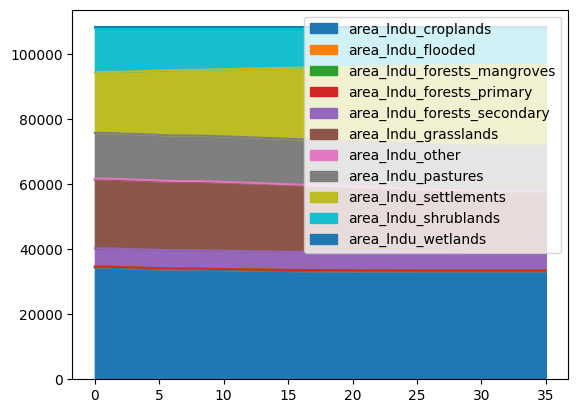

In [488]:
importlib.reload(mafl)
model_afolu = mafl.AFOLU(
    matt,
    force_lurf_for_settlements = False,
)

df_out = model_afolu.project(df_input_cur, )
modvar_lndu = matt.get_variable("Land Use Area")
modvar_lndu.get_from_dataframe(df_out).plot.area()



In [486]:
[x for x in df_out if "ippu" in x and "wood" in x]


<Axes: xlabel='year'>

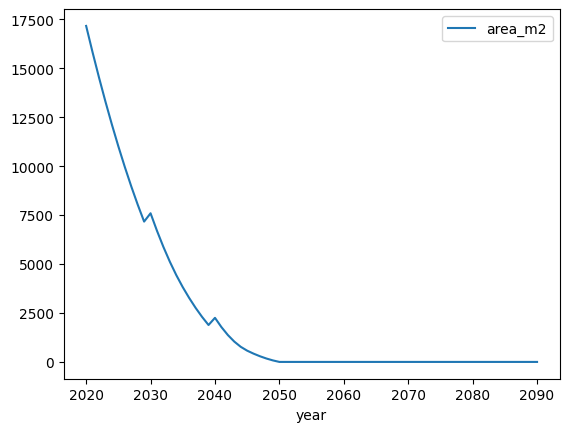

In [80]:


df = df_data[
    df_data["start"].isin(["forests_secondary"])
    & df_data["end"].isin(["settlements"])
]

df2 = split_transition_by_year_interpolate(df)
df2[[_FIELD_YEAR, _FIELD_AREA_M2]].plot(x = "year")

In [115]:
df_fields = add_ssp_field(df_data, model_afolu, )

df_years = pd.DataFrame(
    {
        _FIELD_YEAR: range(2020, 2091)
    }
)


df_fields_full = (
    pd.merge(
        df_years,
        df_fields,#[[_FIELD_YEAR, field]],
        "left",
    )
    .interpolate(
        method = "spline", 
        order = 2, 
    )
)

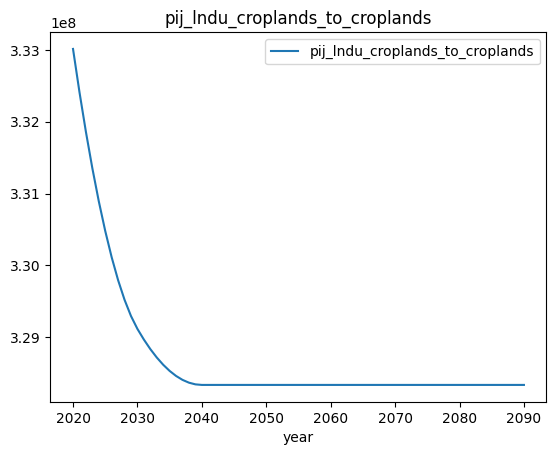

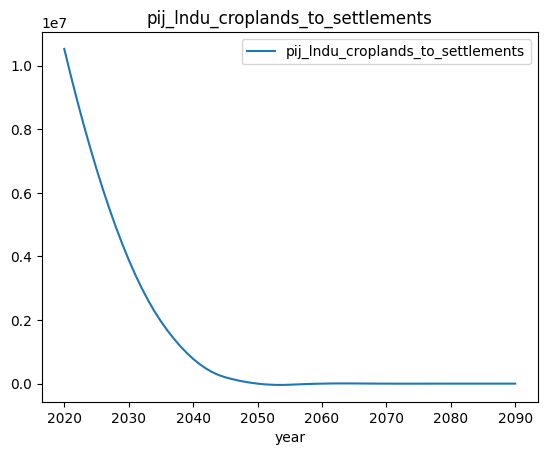

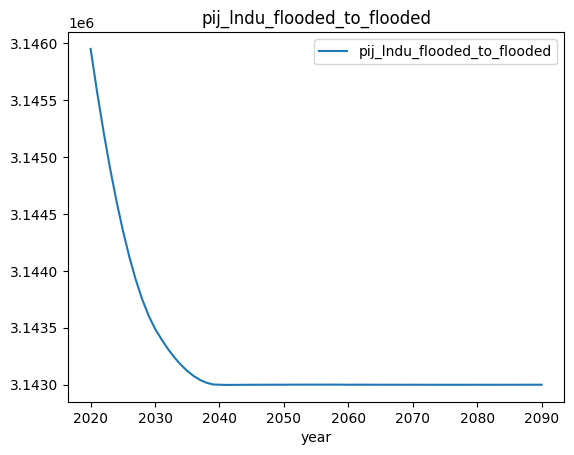

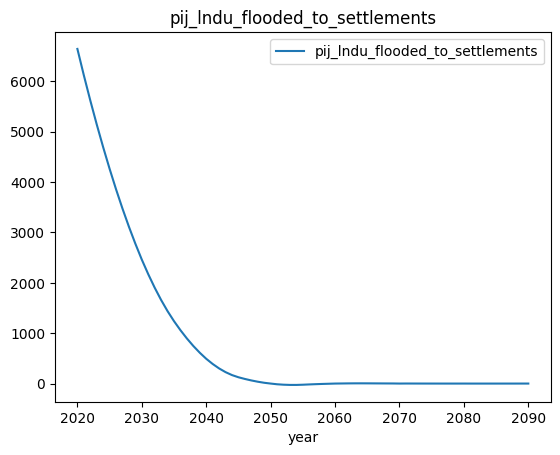

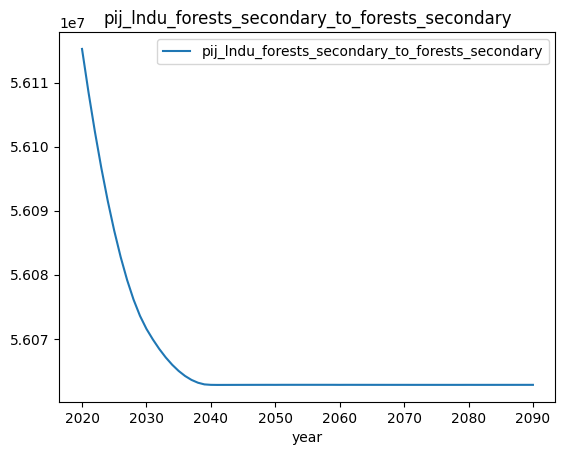

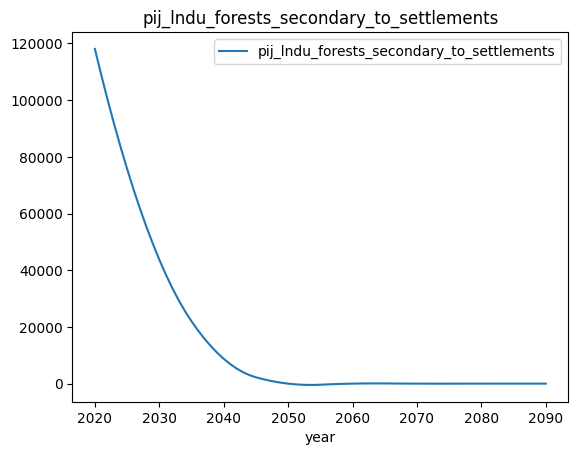

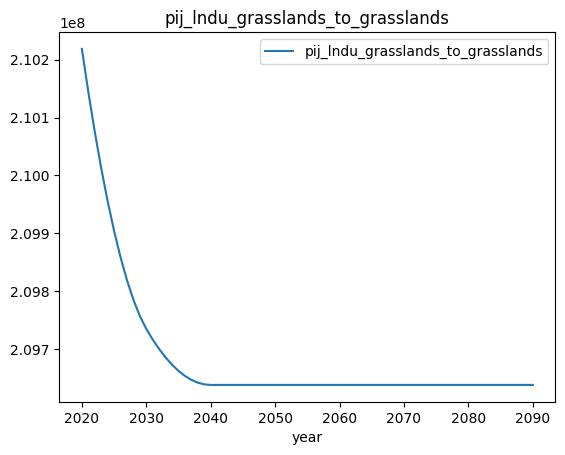

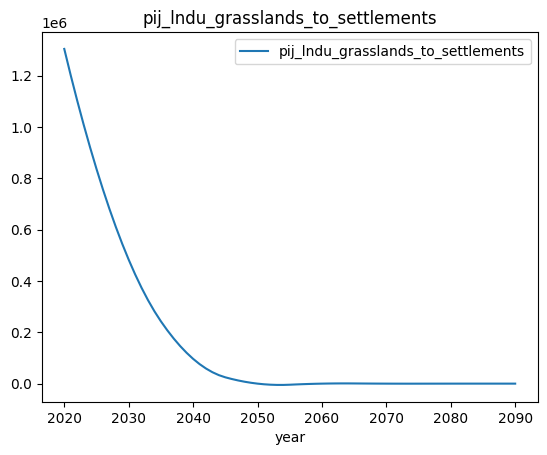

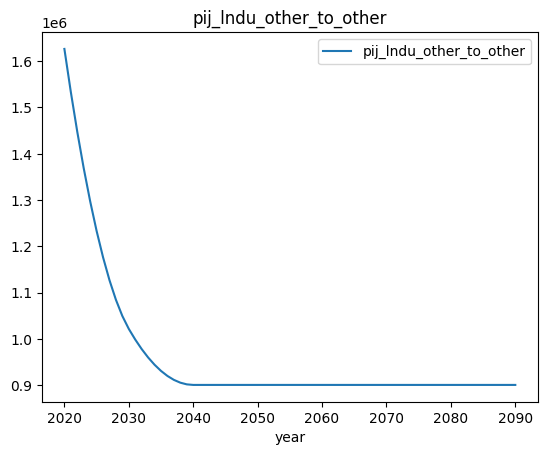

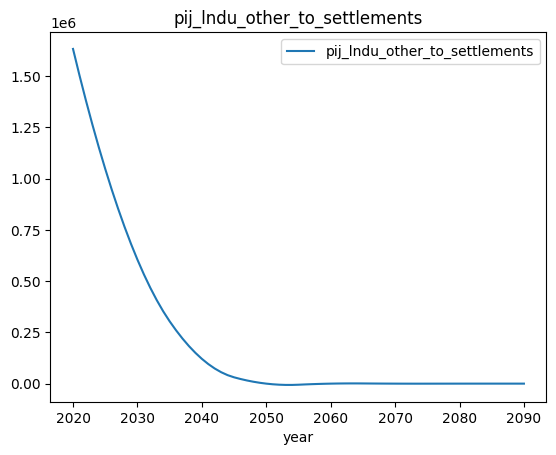

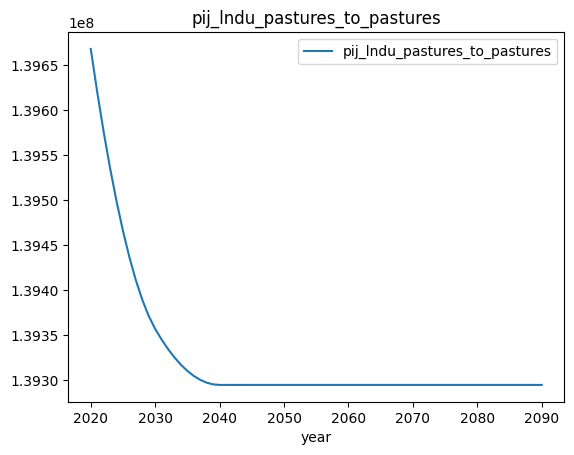

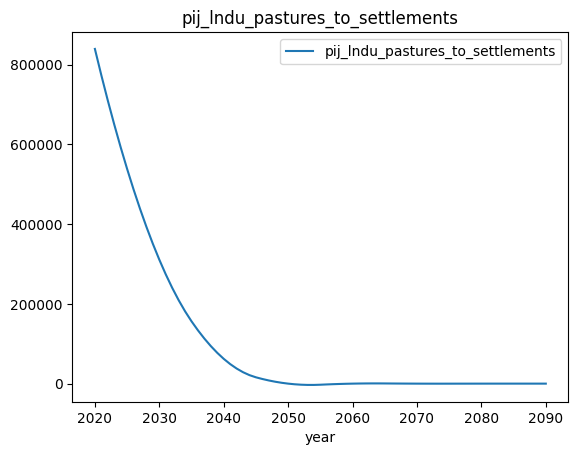

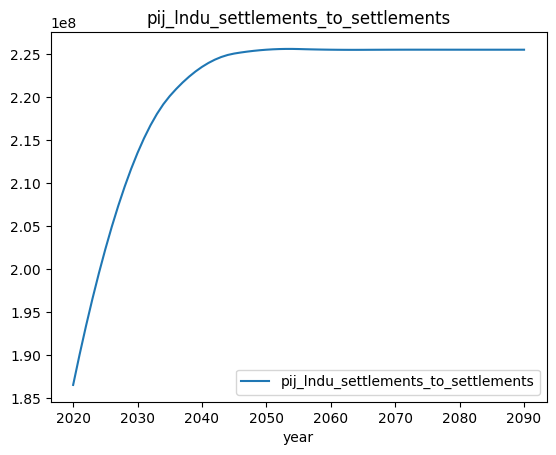

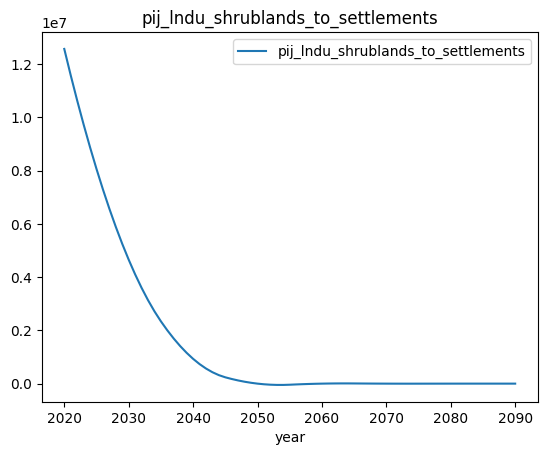

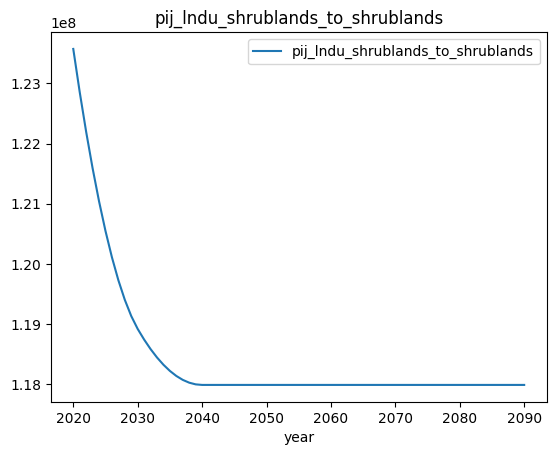

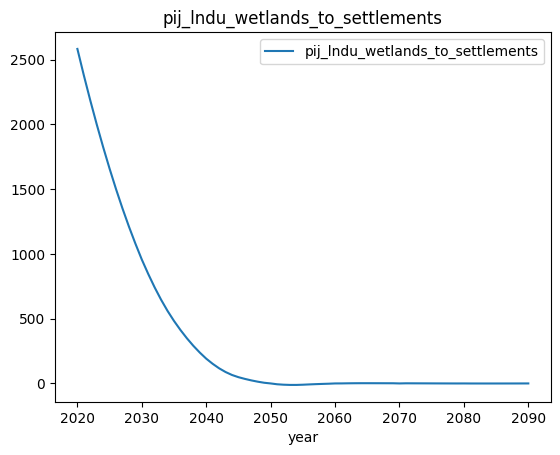

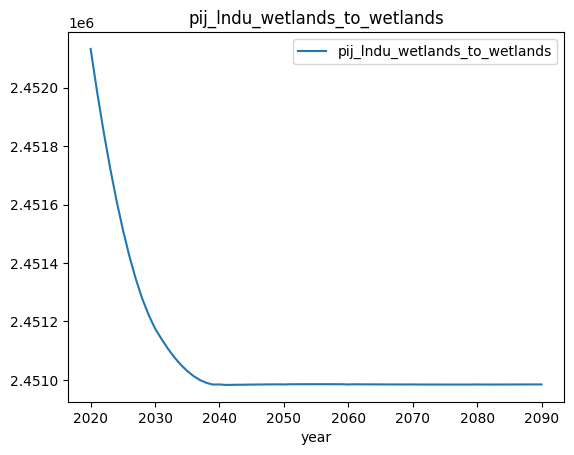

In [103]:
df_fields = add_ssp_field(df_data, model_afolu, )

df_years = pd.DataFrame(
    {
        _FIELD_YEAR: range(2020, 2091)
    }
)


df_fields_full = (
    pd.merge(
        df_years,
        df_fields,#[[_FIELD_YEAR, field]],
        "left",
    )
    .interpolate(
        method = "spline", 
        order = 2, 
    )
)



for field in df_fields_full.columns:
    if field == _FIELD_YEAR: continue    
    if df_fields_full[field].max() == 0: continue
    
    df_fields_full[[_FIELD_YEAR, field]].plot(
        x = _FIELD_YEAR,
        title = field,
    )

In [ ]:
np.round(
    df_fields_full.drop(columns = ["year"]).sum(axis = 1)/10e9, 
    decimals = 4,
).unique()